# Phase 8 — Ablation Studies

This notebook measures how individual design choices affected validation performance.

It reuses results from Phases 3–7 for:

1. Data augmentation
2. Frozen versus fine-tuned ResNet18
3. Custom CNN versus transfer learning
4. Hyperparameter tuning

Because all earlier training runs used class-weighted cross-entropy, this notebook trains
one additional model with the **same winning Phase 7 configuration but without class
weights**.

The primary comparison metric is **validation Macro F1**. The test split is not loaded or
evaluated anywhere in this notebook.

In [20]:
from __future__ import annotations

import gc
import json
import os
import random
import sys
import time
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate

        marker_count = sum(
            (candidate / marker).exists()
            for marker in ["src", "data", "results", "notebooks"]
        )

        if marker_count >= 3:
            return candidate

    return start


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from src.datasets.horse_dataset import HorseGrimaceDataset

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}")

Project root: /home/uteam6/computer-vision-equine-grimace-scale
PyTorch version: 2.5.1+cu121


In [21]:
SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {DEVICE}")
print(f"Random seed: {SEED}")

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
Random seed: 42
GPU: Quadro RTX 4000


In [22]:
RESULTS_ROOT = PROJECT_ROOT / "results"

BASELINE_DIR = (
    RESULTS_ROOT
    / "baseline"
)

AUGMENTATION_DIR = (
    RESULTS_ROOT
    / "augmentation_experiments"
)

TRANSFER_DIR = (
    RESULTS_ROOT
    / "transfer_learning"
)

MODEL_COMPARISON_DIR = (
    RESULTS_ROOT
    / "model_comparison"
)

TUNING_DIR = (
    RESULTS_ROOT
    / "hyperparameter_tuning"
)

FINAL_MODEL_DIR = (
    RESULTS_ROOT
    / "final_model"
)

ABLATION_DIR = (
    RESULTS_ROOT
    / "ablation_studies"
)

FIGURES_DIR = (
    ABLATION_DIR
    / "figures"
)

CHECKPOINTS_DIR = (
    ABLATION_DIR
    / "checkpoints"
)

HISTORIES_DIR = (
    ABLATION_DIR
    / "histories"
)

METRICS_DIR = (
    ABLATION_DIR
    / "metrics"
)

for directory in [
    ABLATION_DIR,
    FIGURES_DIR,
    CHECKPOINTS_DIR,
    HISTORIES_DIR,
    METRICS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

TRAIN_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "train.csv"
)

VALIDATION_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "validation.csv"
)

assert TRAIN_CSV.exists(), (
    f"Missing file: {TRAIN_CSV}"
)

assert VALIDATION_CSV.exists(), (
    f"Missing file: {VALIDATION_CSV}"
)

assert BASELINE_DIR.exists(), (
    f"Missing directory: {BASELINE_DIR}"
)

assert AUGMENTATION_DIR.exists(), (
    f"Missing directory: {AUGMENTATION_DIR}"
)

assert TRANSFER_DIR.exists(), (
    f"Missing directory: {TRANSFER_DIR}"
)

assert MODEL_COMPARISON_DIR.exists(), (
    f"Missing directory: {MODEL_COMPARISON_DIR}"
)

assert TUNING_DIR.exists(), (
    f"Missing directory: {TUNING_DIR}"
)

print(f"Training CSV:   {TRAIN_CSV}")
print(f"Validation CSV: {VALIDATION_CSV}")
print()

print("Result directories:")
print(f"Baseline:              {BASELINE_DIR}")
print(f"Augmentation:          {AUGMENTATION_DIR}")
print(f"Transfer learning:     {TRANSFER_DIR}")
print(f"Model comparison:      {MODEL_COMPARISON_DIR}")
print(f"Hyperparameter tuning: {TUNING_DIR}")
print(f"Phase 8 outputs:       {ABLATION_DIR}")

print("\nThe test CSV is deliberately not defined.")

Training CSV:   /home/uteam6/computer-vision-equine-grimace-scale/data/splits/train.csv
Validation CSV: /home/uteam6/computer-vision-equine-grimace-scale/data/splits/validation.csv

Result directories:
Baseline:              /home/uteam6/computer-vision-equine-grimace-scale/results/baseline
Augmentation:          /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments
Transfer learning:     /home/uteam6/computer-vision-equine-grimace-scale/results/transfer_learning
Model comparison:      /home/uteam6/computer-vision-equine-grimace-scale/results/model_comparison
Hyperparameter tuning: /home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning
Phase 8 outputs:       /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies

The test CSV is deliberately not defined.


In [23]:
def read_json(path: Path) -> dict[str, Any]:
    if not path.exists():
        return {}

    with path.open("r", encoding="utf-8") as input_file:
        return json.load(input_file)


def first_existing_path(
    candidates: Iterable[Path],
    required: bool = True,
    description: str = "file",
) -> Path | None:
    for path in candidates:
        if path.exists():
            return path

    if required:
        checked = "\n".join(
            f"  - {path}" for path in candidates
        )
        raise FileNotFoundError(
            f"Could not find {description}. Checked:\n{checked}"
        )

    return None


def nested_value(
    data: Any,
    keys: Iterable[str],
) -> Any:
    if not isinstance(data, dict):
        return None

    for key in keys:
        if key in data and data[key] is not None:
            return data[key]

    for value in data.values():
        if isinstance(value, dict):
            result = nested_value(value, keys)
            if result is not None:
                return result

    return None


MACRO_F1_KEYS = [
    "validation_macro_f1",
    "val_macro_f1",
    "macro_f1",
    "best_validation_macro_f1",
    "best_val_macro_f1",
]

ACCURACY_KEYS = [
    "validation_accuracy",
    "val_accuracy",
    "accuracy",
    "best_validation_accuracy",
    "best_val_accuracy",
]

LOSS_KEYS = [
    "validation_loss",
    "val_loss",
    "loss",
    "best_validation_loss",
    "best_val_loss",
]


def metric_from_json(
    path: Path,
    keys: Iterable[str],
) -> float | None:
    data = read_json(path)
    value = nested_value(data, keys)

    if value is None:
        return None

    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def normalize_columns(dataframe: pd.DataFrame) -> pd.DataFrame:
    result = dataframe.copy()
    result.columns = [
        str(column).strip().lower().replace(" ", "_")
        for column in result.columns
    ]
    return result


def first_metric_column(
    dataframe: pd.DataFrame,
    names: Iterable[str],
) -> str | None:
    for name in names:
        if name in dataframe.columns:
            return name
    return None


def best_history_metrics(
    path: Path,
) -> dict[str, float | None]:
    history = normalize_columns(pd.read_csv(path))

    macro_column = first_metric_column(
        history,
        [
            "validation_macro_f1",
            "val_macro_f1",
            "macro_f1",
        ],
    )

    accuracy_column = first_metric_column(
        history,
        [
            "validation_accuracy",
            "val_accuracy",
            "accuracy",
        ],
    )

    loss_column = first_metric_column(
        history,
        [
            "validation_loss",
            "val_loss",
        ],
    )

    if macro_column is not None:
        selected_index = history[macro_column].astype(float).idxmax()
    elif loss_column is not None:
        selected_index = history[loss_column].astype(float).idxmin()
    else:
        selected_index = history.index[-1]

    row = history.loc[selected_index]

    return {
        "macro_f1": (
            float(row[macro_column])
            if macro_column is not None
            else None
        ),
        "accuracy": (
            float(row[accuracy_column])
            if accuracy_column is not None
            else None
        ),
        "loss": (
            float(row[loss_column])
            if loss_column is not None
            else None
        ),
    }


def collect_metrics(
    json_candidates: Iterable[Path],
    history_candidates: Iterable[Path],
    label: str,
    search_directory: Path | None = None,
    preferred_keywords: Iterable[str] = (),
) -> dict[str, Any]:
    """
    Recover validation metrics from an earlier phase.

    The function first checks the expected filenames. If those do not
    contain usable metrics, it searches all JSON and CSV files inside
    the supplied directory.
    """
    metrics = {
        "model": label,
        "macro_f1": None,
        "accuracy": None,
        "loss": None,
        "source": None,
    }

    macro_f1_names = [
        "validation_macro_f1",
        "val_macro_f1",
        "macro_f1",
        "validation_f1",
        "val_f1",
        "f1_macro",
        "macro_f1_score",
        "best_validation_macro_f1",
        "best_val_macro_f1",
    ]

    accuracy_names = [
        "validation_accuracy",
        "val_accuracy",
        "accuracy",
        "best_validation_accuracy",
        "best_val_accuracy",
    ]

    loss_names = [
        "validation_loss",
        "val_loss",
        "loss",
        "best_validation_loss",
        "best_val_loss",
    ]

    def examine_json(path: Path) -> dict[str, Any] | None:
        try:
            data = read_json(path)
        except Exception:
            return None

        macro_f1 = nested_value(data, macro_f1_names)

        if macro_f1 is None:
            return None

        try:
            macro_f1 = float(macro_f1)
        except (TypeError, ValueError):
            return None

        accuracy = nested_value(data, accuracy_names)
        loss = nested_value(data, loss_names)

        return {
            "model": label,
            "macro_f1": macro_f1,
            "accuracy": (
                float(accuracy)
                if accuracy is not None
                else None
            ),
            "loss": (
                float(loss)
                if loss is not None
                else None
            ),
            "source": str(path.relative_to(PROJECT_ROOT)),
        }

    def examine_csv(path: Path) -> dict[str, Any] | None:
        try:
            dataframe = normalize_columns(
                pd.read_csv(path)
            )
        except Exception:
            return None

        macro_column = first_metric_column(
            dataframe,
            macro_f1_names,
        )

        if macro_column is None:
            return None

        dataframe[macro_column] = pd.to_numeric(
            dataframe[macro_column],
            errors="coerce",
        )

        valid_rows = dataframe.dropna(
            subset=[macro_column]
        )

        if valid_rows.empty:
            return None

        best_index = valid_rows[macro_column].idxmax()
        row = dataframe.loc[best_index]

        accuracy_column = first_metric_column(
            dataframe,
            accuracy_names,
        )

        loss_column = first_metric_column(
            dataframe,
            loss_names,
        )

        return {
            "model": label,
            "macro_f1": float(row[macro_column]),
            "accuracy": (
                float(row[accuracy_column])
                if (
                    accuracy_column is not None
                    and pd.notna(row[accuracy_column])
                )
                else None
            ),
            "loss": (
                float(row[loss_column])
                if (
                    loss_column is not None
                    and pd.notna(row[loss_column])
                )
                else None
            ),
            "source": str(path.relative_to(PROJECT_ROOT)),
        }

    files_to_check: list[Path] = []

    for path in [
        *json_candidates,
        *history_candidates,
    ]:
        if path.exists():
            files_to_check.append(path)

    if search_directory is not None and search_directory.exists():
        discovered_files = [
            *search_directory.rglob("*.json"),
            *search_directory.rglob("*.csv"),
        ]

        keywords = [
            keyword.lower()
            for keyword in preferred_keywords
        ]

        def file_priority(path: Path) -> tuple[int, str]:
            filename = path.name.lower()

            keyword_score = sum(
                keyword in filename
                for keyword in keywords
            )

            return (
                -keyword_score,
                filename,
            )

        discovered_files.sort(key=file_priority)

        for path in discovered_files:
            if path not in files_to_check:
                files_to_check.append(path)

    recovered_results = []

    for path in files_to_check:
        if path.suffix.lower() == ".json":
            recovered = examine_json(path)
        elif path.suffix.lower() == ".csv":
            recovered = examine_csv(path)
        else:
            recovered = None

        if recovered is not None:
            recovered_results.append(recovered)

    if not recovered_results:
        available_files = []

        if (
            search_directory is not None
            and search_directory.exists()
        ):
            available_files = sorted(
                str(path.relative_to(PROJECT_ROOT))
                for path in search_directory.rglob("*")
                if path.is_file()
            )

        raise ValueError(
            f"Could not recover validation Macro F1 for {label}.\n\n"
            "Files found in the phase directory:\n"
            + "\n".join(
                f"  - {path}"
                for path in available_files
            )
        )

    # Prefer files containing the requested keywords.
    keywords = [
        keyword.lower()
        for keyword in preferred_keywords
    ]

    def result_priority(result: dict[str, Any]) -> tuple[int, float]:
        source = result["source"].lower()

        keyword_score = sum(
            keyword in source
            for keyword in keywords
        )

        return (
            keyword_score,
            result["macro_f1"],
        )

    recovered_results.sort(
        key=result_priority,
        reverse=True,
    )

    return recovered_results[0]

In [24]:
baseline_metrics = collect_metrics(
    json_candidates=[
        BASELINE_DIR
        / "validation_metrics.json",

        BASELINE_DIR
        / "baseline_validation_metrics.json",

        BASELINE_DIR
        / "test_metrics.json",
    ],
    history_candidates=[
        BASELINE_DIR
        / "history.csv",

        BASELINE_DIR
        / "baseline_history.csv",

        BASELINE_DIR
        / "training_history.csv",
    ],
    label="Baseline CNN",
    search_directory=BASELINE_DIR,
    preferred_keywords=[
        "baseline",
        "validation",
        "history",
    ],
)

augmented_metrics = collect_metrics(
    json_candidates=[
        AUGMENTATION_DIR
        / "best_augmentation.json",

        AUGMENTATION_DIR
        / "best_augmented_validation_metrics.json",

        AUGMENTATION_DIR
        / "validation_metrics.json",
    ],
    history_candidates=[
        AUGMENTATION_DIR
        / "best_augmented_history.csv",

        AUGMENTATION_DIR
        / "baseline_vs_best_augmentation.csv",

        AUGMENTATION_DIR
        / "history.csv",
    ],
    label="Augmented CNN",
    search_directory=AUGMENTATION_DIR,
    preferred_keywords=[
        "best_augmentation",
        "best_augmented",
        "best",
        "selected",
    ],
)

frozen_metrics = collect_metrics(
    json_candidates=[
        TRANSFER_DIR
        / "resnet18_frozen_validation_metrics.json",
    ],
    history_candidates=[
        TRANSFER_DIR
        / "histories"
        / "resnet18_frozen_history.csv",

        TRANSFER_DIR
        / "resnet18_frozen_history.csv",
    ],
    label="Frozen ResNet18",
    search_directory=TRANSFER_DIR,
    preferred_keywords=[
        "resnet18_frozen",
        "frozen",
    ],
)

finetuned_metrics = collect_metrics(
    json_candidates=[
        TRANSFER_DIR
        / "resnet18_finetuned_validation_metrics.json",
    ],
    history_candidates=[
        TRANSFER_DIR
        / "histories"
        / "resnet18_finetuned_history.csv",

        TRANSFER_DIR
        / "resnet18_finetuned_history.csv",
    ],
    label="Fine-tuned ResNet18",
    search_directory=TRANSFER_DIR,
    preferred_keywords=[
        "resnet18_finetuned",
        "finetuned",
        "fine_tuned",
    ],
)

print("Recovered metrics:\n")

print("Baseline CNN:")
print(baseline_metrics)

print("\nAugmented CNN:")
print(augmented_metrics)

print("\nFrozen ResNet18:")
print(frozen_metrics)

print("\nFine-tuned ResNet18:")
print(finetuned_metrics)


phase_6_path = first_existing_path(
    [
        MODEL_COMPARISON_DIR
        / "model_comparison.csv",

        MODEL_COMPARISON_DIR
        / "validation_model_comparison.csv",

        MODEL_COMPARISON_DIR
        / "comparison_table.csv",
    ],
    required=False,
)

if phase_6_path is not None:
    phase_6_df = normalize_columns(
        pd.read_csv(phase_6_path)
    )

    print(
        "\nPhase 6 comparison table:"
    )

    display(phase_6_df)

else:
    phase_6_df = pd.DataFrame()

    print(
        "\nPhase 6 comparison CSV was not found. "
        "The notebook will use the Phase 3–5 metrics directly."
    )


preferred_phase_7_files = [
    TUNING_DIR / "tuning_results.csv",
    TUNING_DIR / "experiment_summary.csv",
    TUNING_DIR / "hyperparameter_results.csv",
    TUNING_DIR / "all_experiments.csv",
    TUNING_DIR / "hyperparameter_tuning_results.csv",
    TUNING_DIR / "tuning_summary.csv",
    TUNING_DIR / "phase_7_results.csv",
    TUNING_DIR / "phase_7_summary.csv",
]

phase_7_summary_path = first_existing_path(
    preferred_phase_7_files,
    required=False,
)

# If none of the expected filenames exist, inspect every CSV
# inside the Phase 7 directory and select one containing
# validation Macro F1 and hyperparameter columns.
if phase_7_summary_path is None:
    phase_7_csv_files = sorted(
        TUNING_DIR.rglob("*.csv")
    )

    print("\nCSV files found inside Phase 7:")

    for csv_path in phase_7_csv_files:
        print(
            " -",
            csv_path.relative_to(PROJECT_ROOT),
        )

    candidate_summaries = []

    for csv_path in phase_7_csv_files:
        try:
            candidate_df = normalize_columns(
                pd.read_csv(csv_path)
            )
        except Exception as error:
            print(
                f"Skipping {csv_path.name}: {error}"
            )
            continue

        candidate_columns = set(
            candidate_df.columns
        )

        has_macro_f1 = any(
            column in candidate_columns
            for column in [
                "validation_macro_f1",
                "val_macro_f1",
                "macro_f1",
                "best_validation_macro_f1",
                "best_val_macro_f1",
            ]
        )

        has_hyperparameters = any(
            column in candidate_columns
            for column in [
                "learning_rate",
                "lr",
                "backbone_learning_rate",
                "classifier_learning_rate",
                "dropout",
                "dropout_rate",
                "weight_decay",
            ]
        )

        has_multiple_rows = (
            len(candidate_df) >= 2
        )

        if (
            has_macro_f1
            and has_multiple_rows
        ):
            score = 0

            if has_hyperparameters:
                score += 10

            filename = csv_path.name.lower()

            for keyword in [
                "summary",
                "results",
                "tuning",
                "experiment",
                "comparison",
            ]:
                if keyword in filename:
                    score += 1

            candidate_summaries.append(
                {
                    "path": csv_path,
                    "score": score,
                    "rows": len(candidate_df),
                    "columns": candidate_df.columns.tolist(),
                }
            )

    if not candidate_summaries:
        raise FileNotFoundError(
            "Could not identify the Phase 7 tuning summary. "
            "No CSV file contained validation Macro F1 results "
            "for multiple configurations."
        )

    candidate_summaries = sorted(
        candidate_summaries,
        key=lambda item: (
            item["score"],
            item["rows"],
        ),
        reverse=True,
    )

    phase_7_summary_path = (
        candidate_summaries[0]["path"]
    )

    print(
        "\nAutomatically selected Phase 7 summary:"
    )

    print(
        phase_7_summary_path.relative_to(
            PROJECT_ROOT
        )
    )

    print(
        "\nDetected columns:"
    )

    print(
        candidate_summaries[0]["columns"]
    )

phase_7_df = normalize_columns(
    pd.read_csv(
        phase_7_summary_path
    )
)

print(
    "\nPhase 7 tuning table:"
)

display(phase_7_df)

Recovered metrics:

Baseline CNN:
{'model': 'Baseline CNN', 'macro_f1': 0.5976688309753474, 'accuracy': 0.726984126984127, 'loss': 0.7869469513968815, 'source': 'results/baseline/training_history.csv'}

Augmented CNN:
{'model': 'Augmented CNN', 'macro_f1': 0.6362921324299485, 'accuracy': 0.7396825396825397, 'loss': 0.7618550376286582, 'source': 'results/augmentation_experiments/best_augmented_history.csv'}

Frozen ResNet18:
{'model': 'Frozen ResNet18', 'macro_f1': 0.6432573029211685, 'accuracy': 0.7492063492063492, 'loss': 0.6737239220785716, 'source': 'results/transfer_learning/histories/resnet18_frozen_history.csv'}

Fine-tuned ResNet18:
{'model': 'Fine-tuned ResNet18', 'macro_f1': 0.7037039720345583, 'accuracy': 0.7873015873015873, 'loss': 0.6199899117151896, 'source': 'results/transfer_learning/histories/resnet18_finetuned_history.csv'}

Phase 6 comparison CSV was not found. The notebook will use the Phase 3–5 metrics directly.

CSV files found inside Phase 7:
 - results/hyperparam

,experiment_id,learning_rate,dropout,weight_decay,changed_parameter,training_mode,best_epoch,epochs_completed,elapsed_seconds,validation_loss,validation_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1,validation_weighted_f1,checkpoint_path,history_path,predictions_path
0,config_01_reference,0.0010,0.5,0.0001,reference,fine_tuned,5,10,72.490841,0.623344,0.711111,0.621112,0.671759,0.604733,0.721894,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
1,config_02_lr_low,0.0003,0.5,0.0001,learning_rate,fine_tuned,4,12,89.458409,0.587848,0.790476,0.707654,0.707855,0.707682,0.790835,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
2,config_03_lr_high,0.0030,0.5,0.0001,learning_rate,fine_tuned,10,10,74.569697,0.569482,0.755556,0.661529,0.708620,0.675129,0.767807,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
3,config_04_dropout_low,0.0010,0.3,0.0001,dropout,fine_tuned,10,12,90.331916,0.698892,0.742857,0.651447,0.689350,0.661060,0.744105,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
4,config_05_dropout_high,0.0010,0.7,0.0001,dropout,fine_tuned,7,9,67.607063,0.707592,0.698413,0.550748,0.556910,0.523148,0.682753,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
5,config_06_no_weight_decay,0.0010,0.5,0.0000,weight_decay,fine_tuned,5,10,74.979404,0.651573,0.707937,0.613298,0.657955,0.609051,0.723411,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...
6,config_07_weight_decay_high,0.0010,0.5,0.0010,weight_decay,fine_tuned,5,10,75.383895,0.644508,0.701587,0.615510,0.642240,0.597015,0.716121,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...,/home/uteam6/computer-vision-equine-grimace-sc...


In [25]:
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)
print("AUGMENTATION_DIR:", AUGMENTATION_DIR)

print("\nDoes results exist?")
print(RESULTS_ROOT.exists())

print("\nDoes augmentation directory exist?")
print(AUGMENTATION_DIR.exists())

print("\nFolders inside results:")
if RESULTS_ROOT.exists():
    for path in sorted(RESULTS_ROOT.iterdir()):
        print(
            "[DIR] " if path.is_dir() else "[FILE]",
            path.name,
        )

print("\nAll CSV and JSON files inside results:")
if RESULTS_ROOT.exists():
    for path in sorted(RESULTS_ROOT.rglob("*")):
        if (
            path.is_file()
            and path.suffix.lower() in {".csv", ".json"}
        ):
            print(path.relative_to(PROJECT_ROOT))

PROJECT_ROOT: /home/uteam6/computer-vision-equine-grimace-scale
RESULTS_ROOT: /home/uteam6/computer-vision-equine-grimace-scale/results
AUGMENTATION_DIR: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments

Does results exist?
True

Does augmentation directory exist?
True

Folders inside results:
[DIR]  ablation_studies
[DIR]  augmentation_experiments
[DIR]  baseline
[DIR]  final_model
[DIR]  hyperparameter_tuning
[DIR]  model_comparison
[DIR]  transfer_learning

All CSV and JSON files inside results:
results/augmentation_experiments/affine_validation_metrics.json
results/augmentation_experiments/baseline_vs_best_augmentation.csv
results/augmentation_experiments/best_augmentation.json
results/augmentation_experiments/best_augmented_history.csv
results/augmentation_experiments/color_jitter_validation_metrics.json
results/augmentation_experiments/combined_validation_metrics.json
results/augmentation_experiments/experiment_summary.csv
results/augmentation_ex

In [26]:
tuning_macro_column = first_metric_column(
    phase_7_df,
    [
        "validation_macro_f1",
        "val_macro_f1",
        "macro_f1",
    ],
)

assert tuning_macro_column is not None, (
    "The Phase 7 summary does not contain a Macro F1 column. "
    f"Available columns: {phase_7_df.columns.tolist()}"
)

tuning_accuracy_column = first_metric_column(
    phase_7_df,
    [
        "validation_accuracy",
        "val_accuracy",
        "accuracy",
    ],
)

configuration_column = first_metric_column(
    phase_7_df,
    [
        "configuration",
        "experiment_name",
        "name",
        "run_name",
        "config_name",
    ],
)

if configuration_column is None:
    phase_7_df["configuration"] = [
        f"Configuration {index + 1}"
        for index in range(len(phase_7_df))
    ]
    configuration_column = "configuration"

phase_7_df[tuning_macro_column] = (
    phase_7_df[tuning_macro_column].astype(float)
)

best_tuned_index = (
    phase_7_df[tuning_macro_column].idxmax()
)

best_tuned_row = phase_7_df.loc[best_tuned_index].copy()

reference_mask = (
    phase_7_df[configuration_column]
    .astype(str)
    .str.lower()
    .str.contains("reference|default|phase_6|phase6|original")
)

if reference_mask.any():
    reference_row = (
        phase_7_df.loc[reference_mask]
        .sort_values(
            tuning_macro_column,
            ascending=False,
        )
        .iloc[0]
        .copy()
    )
else:
    reference_row = phase_7_df.iloc[0].copy()

reference_metrics = {
    "model": "Reference configuration",
    "macro_f1": float(reference_row[tuning_macro_column]),
    "accuracy": (
        float(reference_row[tuning_accuracy_column])
        if tuning_accuracy_column is not None
        else None
    ),
}

best_tuned_metrics = {
    "model": "Best tuned configuration",
    "macro_f1": float(best_tuned_row[tuning_macro_column]),
    "accuracy": (
        float(best_tuned_row[tuning_accuracy_column])
        if tuning_accuracy_column is not None
        else None
    ),
}

print("Reference configuration:")
display(reference_row.to_frame("value"))

print("\nBest tuned configuration:")
display(best_tuned_row.to_frame("value"))

Reference configuration:


,value
experiment_id,config_01_reference
learning_rate,0.001
dropout,0.5
weight_decay,0.0001
changed_parameter,reference
training_mode,fine_tuned
best_epoch,5
epochs_completed,10
elapsed_seconds,72.490841
validation_loss,0.623344



Best tuned configuration:


,value
experiment_id,config_02_lr_low
learning_rate,0.0003
dropout,0.5
weight_decay,0.0001
changed_parameter,learning_rate
training_mode,fine_tuned
best_epoch,4
epochs_completed,12
elapsed_seconds,89.458409
validation_loss,0.587848


In [27]:
def save_two_model_comparison(
    dataframe: pd.DataFrame,
    title: str,
    output_path: Path,
) -> None:
    figure, axis = plt.subplots(figsize=(7, 5))

    bars = axis.bar(
        dataframe["model"],
        dataframe["macro_f1"],
    )

    axis.set_title(title)
    axis.set_ylabel("Validation Macro F1")
    axis.set_ylim(
        0,
        min(
            1.0,
            max(dataframe["macro_f1"]) + 0.12,
        ),
    )

    axis.tick_params(
        axis="x",
        rotation=12,
    )

    for bar, value in zip(
        bars,
        dataframe["macro_f1"],
    ):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.01,
            f"{value:.4f}",
            ha="center",
            va="bottom",
        )

    figure.tight_layout()
    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print(f"Saved: {output_path}")

,model,macro_f1,accuracy,change_from_baseline
0,Baseline CNN,0.5977,0.7270,+0.0000
1,Augmented CNN,0.6363,0.7397,+0.0386


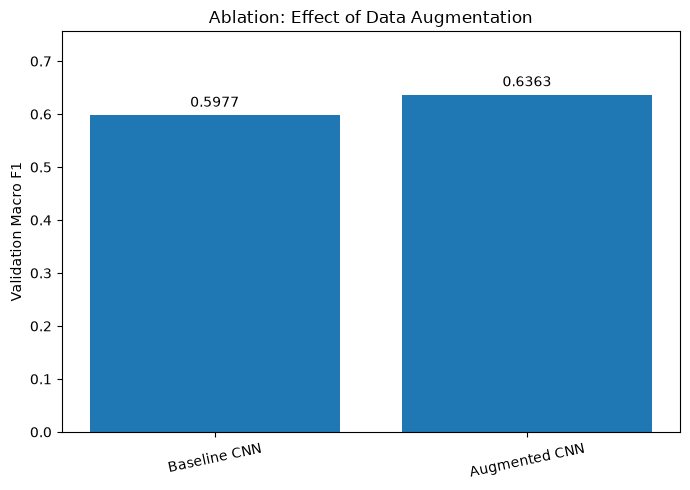

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies/figures/augmentation_ablation.png


**Conclusion.** Data augmentation improved validation Macro F1 by 0.0386. This suggests that the augmented training images improved generalization.

In [28]:
augmentation_ablation = pd.DataFrame(
    [
        baseline_metrics,
        augmented_metrics,
    ]
)[
    ["model", "macro_f1", "accuracy"]
]

augmentation_improvement = (
    augmented_metrics["macro_f1"]
    - baseline_metrics["macro_f1"]
)

augmentation_ablation["change_from_baseline"] = [
    0.0,
    augmentation_improvement,
]

display(
    augmentation_ablation.style.format(
        {
            "macro_f1": "{:.4f}",
            "accuracy": (
                lambda value: ""
                if pd.isna(value)
                else f"{value:.4f}"
            ),
            "change_from_baseline": "{:+.4f}",
        }
    )
)

save_two_model_comparison(
    augmentation_ablation,
    title="Ablation: Effect of Data Augmentation",
    output_path=FIGURES_DIR / "augmentation_ablation.png",
)

if augmentation_improvement > 0:
    augmentation_conclusion = (
        f"Data augmentation improved validation Macro F1 by "
        f"{augmentation_improvement:.4f}. This suggests that the "
        "augmented training images improved generalization."
    )
elif augmentation_improvement < 0:
    augmentation_conclusion = (
        f"Data augmentation reduced validation Macro F1 by "
        f"{abs(augmentation_improvement):.4f}. The selected augmentation "
        "may have introduced transformations that were too aggressive."
    )
else:
    augmentation_conclusion = (
        "Data augmentation produced no measurable change in validation "
        "Macro F1."
    )

display(Markdown(f"**Conclusion.** {augmentation_conclusion}"))

,model,macro_f1,accuracy,change_from_frozen
0,Frozen ResNet18,0.6433,0.7492,+0.0000
1,Fine-tuned ResNet18,0.7037,0.7873,+0.0604


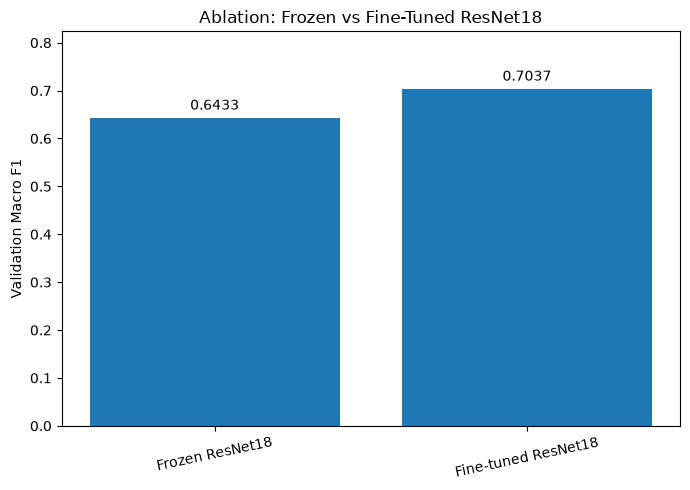

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies/figures/fine_tuning_ablation.png


**Conclusion.** Fine-tuning improved validation Macro F1 by 0.0604. Updating the pretrained backbone helped adapt ImageNet features to horse facial pain cues.

In [29]:
fine_tuning_ablation = pd.DataFrame(
    [
        frozen_metrics,
        finetuned_metrics,
    ]
)[
    ["model", "macro_f1", "accuracy"]
]

fine_tuning_improvement = (
    finetuned_metrics["macro_f1"]
    - frozen_metrics["macro_f1"]
)

fine_tuning_ablation["change_from_frozen"] = [
    0.0,
    fine_tuning_improvement,
]

display(
    fine_tuning_ablation.style.format(
        {
            "macro_f1": "{:.4f}",
            "accuracy": (
                lambda value: ""
                if pd.isna(value)
                else f"{value:.4f}"
            ),
            "change_from_frozen": "{:+.4f}",
        }
    )
)

save_two_model_comparison(
    fine_tuning_ablation,
    title="Ablation: Frozen vs Fine-Tuned ResNet18",
    output_path=FIGURES_DIR / "fine_tuning_ablation.png",
)

if fine_tuning_improvement > 0:
    fine_tuning_conclusion = (
        f"Fine-tuning improved validation Macro F1 by "
        f"{fine_tuning_improvement:.4f}. Updating the pretrained backbone "
        "helped adapt ImageNet features to horse facial pain cues."
    )
elif fine_tuning_improvement < 0:
    fine_tuning_conclusion = (
        f"Fine-tuning reduced validation Macro F1 by "
        f"{abs(fine_tuning_improvement):.4f}. The frozen representation "
        "generalized better under the selected training settings."
    )
else:
    fine_tuning_conclusion = (
        "Frozen and fine-tuned ResNet18 obtained the same validation "
        "Macro F1."
    )

display(Markdown(f"**Conclusion.** {fine_tuning_conclusion}"))

,model,macro_f1,accuracy,change_from_cnn
0,Best CNN (Augmented CNN),0.6363,0.7397,+0.0000
1,Best ResNet18 (Fine-tuned ResNet18),0.7037,0.7873,+0.0674


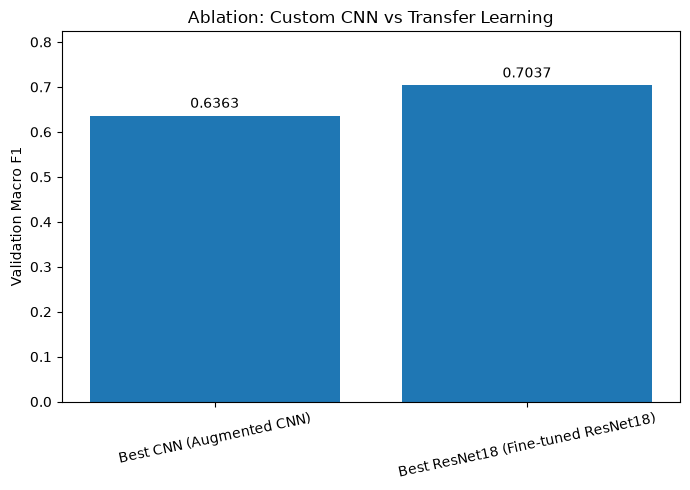

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies/figures/transfer_learning_ablation.png


**Conclusion.** Transfer learning improved validation Macro F1 by 0.0674. The pretrained ResNet18 backbone provided stronger visual features than learning entirely from scratch on the smaller horse dataset.

In [30]:
best_cnn_metrics = max(
    [baseline_metrics, augmented_metrics],
    key=lambda item: item["macro_f1"],
)

best_transfer_metrics = max(
    [frozen_metrics, finetuned_metrics],
    key=lambda item: item["macro_f1"],
)

transfer_ablation = pd.DataFrame(
    [
        {
            **best_cnn_metrics,
            "model": f"Best CNN ({best_cnn_metrics['model']})",
        },
        {
            **best_transfer_metrics,
            "model": (
                f"Best ResNet18 "
                f"({best_transfer_metrics['model']})"
            ),
        },
    ]
)[
    ["model", "macro_f1", "accuracy"]
]

transfer_improvement = (
    best_transfer_metrics["macro_f1"]
    - best_cnn_metrics["macro_f1"]
)

transfer_ablation["change_from_cnn"] = [
    0.0,
    transfer_improvement,
]

display(
    transfer_ablation.style.format(
        {
            "macro_f1": "{:.4f}",
            "accuracy": (
                lambda value: ""
                if pd.isna(value)
                else f"{value:.4f}"
            ),
            "change_from_cnn": "{:+.4f}",
        }
    )
)

save_two_model_comparison(
    transfer_ablation,
    title="Ablation: Custom CNN vs Transfer Learning",
    output_path=FIGURES_DIR / "transfer_learning_ablation.png",
)

if transfer_improvement > 0:
    transfer_conclusion = (
        f"Transfer learning improved validation Macro F1 by "
        f"{transfer_improvement:.4f}. The pretrained ResNet18 backbone "
        "provided stronger visual features than learning entirely from "
        "scratch on the smaller horse dataset."
    )
elif transfer_improvement < 0:
    transfer_conclusion = (
        f"The best custom CNN exceeded the best ResNet18 by "
        f"{abs(transfer_improvement):.4f} Macro F1."
    )
else:
    transfer_conclusion = (
        "The best custom CNN and best ResNet18 obtained the same "
        "validation Macro F1."
    )

display(Markdown(f"**Conclusion.** {transfer_conclusion}"))

,model,macro_f1,accuracy,change_from_reference
0,Reference configuration,0.6047,0.7111,+0.0000
1,Best tuned configuration,0.7077,0.7905,+0.1029


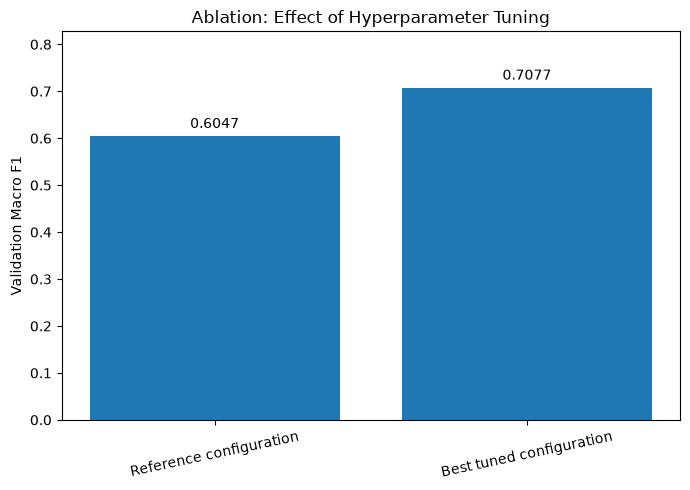

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies/figures/hyperparameter_ablation.png


**Conclusion.** Hyperparameter tuning improved validation Macro F1 by 0.1029 over the reference configuration.

In [31]:
hyperparameter_ablation = pd.DataFrame(
    [
        reference_metrics,
        best_tuned_metrics,
    ]
)

hyperparameter_improvement = (
    best_tuned_metrics["macro_f1"]
    - reference_metrics["macro_f1"]
)

hyperparameter_ablation["change_from_reference"] = [
    0.0,
    hyperparameter_improvement,
]

display(
    hyperparameter_ablation.style.format(
        {
            "macro_f1": "{:.4f}",
            "accuracy": (
                lambda value: ""
                if pd.isna(value)
                else f"{value:.4f}"
            ),
            "change_from_reference": "{:+.4f}",
        }
    )
)

save_two_model_comparison(
    hyperparameter_ablation,
    title="Ablation: Effect of Hyperparameter Tuning",
    output_path=FIGURES_DIR / "hyperparameter_ablation.png",
)

if hyperparameter_improvement > 0:
    tuning_conclusion = (
        f"Hyperparameter tuning improved validation Macro F1 by "
        f"{hyperparameter_improvement:.4f} over the reference "
        "configuration."
    )
elif hyperparameter_improvement < 0:
    tuning_conclusion = (
        f"The best recorded tuned configuration was "
        f"{abs(hyperparameter_improvement):.4f} below the reference. "
        "Therefore, the reference configuration should remain preferred."
    )
else:
    tuning_conclusion = (
        "Hyperparameter tuning matched, but did not exceed, the reference "
        "validation Macro F1."
    )

display(Markdown(f"**Conclusion.** {tuning_conclusion}"))

In [32]:
RUN_CLASS_WEIGHT_ABLATION = True

NUM_CLASSES = 3
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = DEVICE.type == "cuda"

UNWEIGHTED_CHECKPOINT_PATH = (
    CHECKPOINTS_DIR / "resnet18_unweighted_best.pth"
)

UNWEIGHTED_HISTORY_PATH = (
    HISTORIES_DIR / "resnet18_unweighted_history.csv"
)

UNWEIGHTED_METRICS_PATH = (
    METRICS_DIR / "resnet18_unweighted_validation_metrics.json"
)

print(f"Run unweighted training: {RUN_CLASS_WEIGHT_ABLATION}")
print(f"Checkpoint: {UNWEIGHTED_CHECKPOINT_PATH}")

Run unweighted training: True
Checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies/checkpoints/resnet18_unweighted_best.pth


In [33]:
def numeric_from_row(
    row: pd.Series,
    names: Iterable[str],
    default: float,
) -> float:
    for name in names:
        if name in row.index and pd.notna(row[name]):
            try:
                return float(row[name])
            except (TypeError, ValueError):
                pass
    return float(default)


WINNING_BACKBONE_LEARNING_RATE = numeric_from_row(
    best_tuned_row,
    [
        "backbone_learning_rate",
        "backbone_lr",
        "learning_rate",
        "lr",
        "base_learning_rate",
    ],
    default=1e-4,
)

WINNING_CLASSIFIER_LEARNING_RATE = numeric_from_row(
    best_tuned_row,
    [
        "classifier_learning_rate",
        "classifier_lr",
        "head_learning_rate",
        "head_lr",
        "learning_rate",
        "lr",
    ],
    default=WINNING_BACKBONE_LEARNING_RATE,
)

WINNING_DROPOUT = numeric_from_row(
    best_tuned_row,
    [
        "dropout",
        "dropout_rate",
    ],
    default=0.3,
)

WINNING_WEIGHT_DECAY = numeric_from_row(
    best_tuned_row,
    [
        "weight_decay",
    ],
    default=1e-4,
)

WINNING_EPOCHS = int(
    numeric_from_row(
        best_tuned_row,
        [
            "num_epochs",
            "epochs",
            "maximum_epochs",
        ],
        default=20,
    )
)

WINNING_PATIENCE = int(
    numeric_from_row(
        best_tuned_row,
        [
            "early_stopping_patience",
            "patience",
        ],
        default=6,
    )
)

phase_5_metadata = read_json(
    TRANSFER_DIR / "best_transfer_model.json"
)

training_mode_text = str(
    phase_5_metadata.get(
        "training_mode",
        phase_5_metadata.get(
            "selected_training_mode",
            "fine_tuned",
        ),
    )
).lower()

WINNING_TRAINING_MODE = (
    "frozen"
    if "frozen" in training_mode_text
    else "fine_tuned"
)

print(f"Training mode: {WINNING_TRAINING_MODE}")
print(
    "Backbone learning rate:   "
    f"{WINNING_BACKBONE_LEARNING_RATE}"
)
print(
    "Classifier learning rate: "
    f"{WINNING_CLASSIFIER_LEARNING_RATE}"
)
print(f"Dropout:       {WINNING_DROPOUT}")
print(f"Weight decay:  {WINNING_WEIGHT_DECAY}")
print(f"Epochs:        {WINNING_EPOCHS}")
print(f"Patience:      {WINNING_PATIENCE}")

Training mode: fine_tuned
Backbone learning rate:   0.0003
Classifier learning rate: 0.0003
Dropout:       0.5
Weight decay:  0.0001
Epochs:        20
Patience:      6


In [34]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            IMAGE_SIZE,
            scale=(0.80, 1.00),
            ratio=(0.90, 1.10),
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

validation_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

train_dataset = HorseGrimaceDataset(
    csv_file=TRAIN_CSV,
    image_root=PROJECT_ROOT,
    transform=train_transform,
    verify_images=True,
)

validation_dataset = HorseGrimaceDataset(
    csv_file=VALIDATION_CSV,
    image_root=PROJECT_ROOT,
    transform=validation_transform,
    verify_images=True,
)

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

print(f"Training samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(validation_dataset):,}")
print(f"Training batches:   {len(train_loader):,}")
print(f"Validation batches: {len(validation_loader):,}")

Training samples:   2,581
Validation samples: 315
Training batches:   81
Validation batches: 10


In [35]:
def build_resnet18(
    dropout_rate: float,
    training_mode: str,
) -> nn.Module:
    model = resnet18(
        weights=ResNet18_Weights.DEFAULT
    )

    input_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(input_features, NUM_CLASSES),
    )

    if training_mode == "frozen":
        for parameter in model.parameters():
            parameter.requires_grad = False

        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    elif training_mode == "fine_tuned":
        for parameter in model.parameters():
            parameter.requires_grad = True

    else:
        raise ValueError(
            f"Unsupported training mode: {training_mode}"
        )

    return model


unweighted_model = build_resnet18(
    dropout_rate=WINNING_DROPOUT,
    training_mode=WINNING_TRAINING_MODE,
).to(DEVICE)

trainable_parameters = sum(
    parameter.numel()
    for parameter in unweighted_model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in unweighted_model.parameters()
)

print(f"Total parameters:     {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(unweighted_model.fc)

Total parameters:     11,178,051
Trainable parameters: 11,178,051
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=3, bias=True)
)


In [36]:
def unpack_batch(
    batch: Any,
) -> tuple[torch.Tensor, torch.Tensor]:
    if isinstance(batch, dict):
        images = batch["image"]

        if "pain_score" in batch:
            targets = batch["pain_score"]
        elif "label" in batch:
            targets = batch["label"]
        else:
            raise KeyError(
                "Batch dictionary has no pain_score or label key."
            )

        return images, targets

    if isinstance(batch, (tuple, list)) and len(batch) >= 2:
        return batch[0], batch[1]

    raise TypeError(
        f"Unsupported batch type: {type(batch)}"
    )


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
) -> dict[str, float]:
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0
    all_targets: list[int] = []
    all_predictions: list[int] = []

    context = (
        torch.enable_grad()
        if is_training
        else torch.inference_mode()
    )

    with context:
        for batch in loader:
            images, targets = unpack_batch(batch)

            images = images.to(
                DEVICE,
                non_blocking=True,
            )

            targets = targets.to(
                DEVICE,
                dtype=torch.long,
                non_blocking=True,
            )

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, targets)

            if is_training:
                loss.backward()
                optimizer.step()

            predictions = logits.argmax(dim=1)
            batch_size = targets.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_targets.extend(
                targets.detach().cpu().tolist()
            )

            all_predictions.extend(
                predictions.detach().cpu().tolist()
            )

    targets_array = np.asarray(all_targets)
    predictions_array = np.asarray(all_predictions)

    accuracy = accuracy_score(
        targets_array,
        predictions_array,
    )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            targets_array,
            predictions_array,
            average="macro",
            zero_division=0,
        )
    )

    return {
        "loss": total_loss / max(total_samples, 1),
        "accuracy": float(accuracy),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(macro_f1),
    }

In [37]:
if (
    RUN_CLASS_WEIGHT_ABLATION
    or not UNWEIGHTED_METRICS_PATH.exists()
):
    set_seed()

    unweighted_model = build_resnet18(
        dropout_rate=WINNING_DROPOUT,
        training_mode=WINNING_TRAINING_MODE,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    if WINNING_TRAINING_MODE == "fine_tuned":
        backbone_parameters = [
            parameter
            for name, parameter in unweighted_model.named_parameters()
            if parameter.requires_grad
            and not name.startswith("fc.")
        ]

        classifier_parameters = [
            parameter
            for name, parameter in unweighted_model.named_parameters()
            if parameter.requires_grad
            and name.startswith("fc.")
        ]

        optimizer_parameters = [
            {
                "params": backbone_parameters,
                "lr": WINNING_BACKBONE_LEARNING_RATE,
            },
            {
                "params": classifier_parameters,
                "lr": WINNING_CLASSIFIER_LEARNING_RATE,
            },
        ]
    else:
        optimizer_parameters = [
            {
                "params": [
                    parameter
                    for parameter in unweighted_model.parameters()
                    if parameter.requires_grad
                ],
                "lr": WINNING_CLASSIFIER_LEARNING_RATE,
            }
        ]

    optimizer = torch.optim.Adam(
        optimizer_parameters,
        weight_decay=WINNING_WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
    )

    best_macro_f1 = -np.inf
    best_epoch = 0
    epochs_without_improvement = 0
    history_rows: list[dict[str, float]] = []

    training_start = time.perf_counter()

    for epoch in range(1, WINNING_EPOCHS + 1):
        train_metrics = run_epoch(
            model=unweighted_model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
        )

        validation_metrics = run_epoch(
            model=unweighted_model,
            loader=validation_loader,
            criterion=criterion,
            optimizer=None,
        )

        scheduler.step(
            validation_metrics["macro_f1"]
        )

        current_backbone_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        current_classifier_learning_rate = (
            optimizer.param_groups[-1]["lr"]
        )

        history_row = {
            "epoch": epoch,
            "backbone_learning_rate": (
                current_backbone_learning_rate
            ),
            "classifier_learning_rate": (
                current_classifier_learning_rate
            ),
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "validation_loss": validation_metrics["loss"],
            "validation_accuracy": validation_metrics["accuracy"],
            "validation_macro_precision": (
                validation_metrics["macro_precision"]
            ),
            "validation_macro_recall": (
                validation_metrics["macro_recall"]
            ),
            "validation_macro_f1": (
                validation_metrics["macro_f1"]
            ),
        }

        history_rows.append(history_row)

        print(
            f"Epoch {epoch:02d}/{WINNING_EPOCHS} | "
            f"train loss {train_metrics['loss']:.4f} | "
            f"train F1 {train_metrics['macro_f1']:.4f} | "
            f"val loss {validation_metrics['loss']:.4f} | "
            f"val F1 {validation_metrics['macro_f1']:.4f} | "
            f"backbone lr {current_backbone_learning_rate:.2e} | "
            f"classifier lr {current_classifier_learning_rate:.2e}"
        )

        if (
            validation_metrics["macro_f1"]
            > best_macro_f1 + 1e-6
        ):
            best_macro_f1 = (
                validation_metrics["macro_f1"]
            )
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": (
                        unweighted_model.state_dict()
                    ),
                    "optimizer_state_dict": (
                        optimizer.state_dict()
                    ),
                    "validation_metrics": (
                        validation_metrics
                    ),
                    "configuration": {
                        "training_mode": (
                            WINNING_TRAINING_MODE
                        ),
                        "backbone_learning_rate": (
                            WINNING_BACKBONE_LEARNING_RATE
                        ),
                        "classifier_learning_rate": (
                            WINNING_CLASSIFIER_LEARNING_RATE
                        ),
                        "dropout": WINNING_DROPOUT,
                        "weight_decay": (
                            WINNING_WEIGHT_DECAY
                        ),
                        "class_weights": False,
                    },
                },
                UNWEIGHTED_CHECKPOINT_PATH,
            )
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= WINNING_PATIENCE
        ):
            print(
                "Early stopping: validation Macro F1 "
                f"did not improve for {WINNING_PATIENCE} epochs."
            )
            break

    training_seconds = (
        time.perf_counter() - training_start
    )

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(
        UNWEIGHTED_HISTORY_PATH,
        index=False,
    )

    checkpoint = torch.load(
        UNWEIGHTED_CHECKPOINT_PATH,
        map_location=DEVICE,
        weights_only=False,
    )

    unweighted_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    final_unweighted_metrics = run_epoch(
        model=unweighted_model,
        loader=validation_loader,
        criterion=criterion,
        optimizer=None,
    )

    saved_unweighted_metrics = {
        "validation_loss": (
            final_unweighted_metrics["loss"]
        ),
        "validation_accuracy": (
            final_unweighted_metrics["accuracy"]
        ),
        "validation_macro_precision": (
            final_unweighted_metrics[
                "macro_precision"
            ]
        ),
        "validation_macro_recall": (
            final_unweighted_metrics[
                "macro_recall"
            ]
        ),
        "validation_macro_f1": (
            final_unweighted_metrics["macro_f1"]
        ),
        "best_epoch": int(best_epoch),
        "training_seconds": float(training_seconds),
        "training_mode": WINNING_TRAINING_MODE,
        "backbone_learning_rate": (
            WINNING_BACKBONE_LEARNING_RATE
        ),
        "classifier_learning_rate": (
            WINNING_CLASSIFIER_LEARNING_RATE
        ),
        "dropout": WINNING_DROPOUT,
        "weight_decay": WINNING_WEIGHT_DECAY,
        "class_weights": False,
        "checkpoint": str(
            UNWEIGHTED_CHECKPOINT_PATH.relative_to(
                PROJECT_ROOT
            )
        ),
    }

    with UNWEIGHTED_METRICS_PATH.open(
        "w",
        encoding="utf-8",
    ) as output_file:
        json.dump(
            saved_unweighted_metrics,
            output_file,
            indent=4,
        )

    print(
        f"Unweighted metrics saved: "
        f"{UNWEIGHTED_METRICS_PATH}"
    )

else:
    print(
        "Skipping training and reusing the existing "
        "unweighted metrics file."
    )

gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Epoch 01/20 | train loss 0.7557 | train F1 0.5563 | val loss 0.6944 | val F1 0.6312 | backbone lr 3.00e-04 | classifier lr 3.00e-04
Epoch 02/20 | train loss 0.4970 | train F1 0.7116 | val loss 0.6616 | val F1 0.6852 | backbone lr 3.00e-04 | classifier lr 3.00e-04
Epoch 03/20 | train loss 0.3487 | train F1 0.8126 | val loss 0.7873 | val F1 0.5406 | backbone lr 3.00e-04 | classifier lr 3.00e-04
Epoch 04/20 | train loss 0.2710 | train F1 0.8493 | val loss 0.9206 | val F1 0.6099 | backbone lr 3.00e-04 | classifier lr 3.00e-04
Epoch 05/20 | train loss 0.2396 | train F1 0.8831 | val loss 1.1718 | val F1 0.5697 | backbone lr 1.50e-04 | classifier lr 1.50e-04
Epoch 06/20 | train loss 0.1078 | train F1 0.9532 | val loss 0.7773 | val F1 0.6854 | backbone lr 1.50e-04 | classifier lr 1.50e-04
Epoch 07/20 | train loss 0.0573 | train F1 0.9765 | val loss 0.8484 | val F1 0.6926 | backbone lr 1.50e-04 | classifier lr 1.50e-04
Epoch 08/20 | train loss 0.0260 | train F1 0.9948 | val loss 0.9678 | val F1

,epoch,backbone_learning_rate,classifier_learning_rate,train_loss,train_accuracy,train_macro_f1,validation_loss,validation_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1
15,16,0.000075,0.000075,0.004117,0.999613,0.999596,1.035465,0.774603,0.710394,0.678745,0.692780
16,17,0.000075,0.000075,0.004761,0.999613,0.999596,1.039905,0.784127,0.711751,0.689437,0.698796
17,18,0.000037,0.000037,0.003210,1.000000,1.000000,1.020619,0.790476,0.734490,0.686955,0.707054
18,19,0.000037,0.000037,0.002290,0.999613,0.999498,0.964585,0.790476,0.728533,0.699387,0.712439
19,20,0.000037,0.000037,0.002399,1.000000,1.000000,1.042439,0.793651,0.736146,0.688598,0.708393


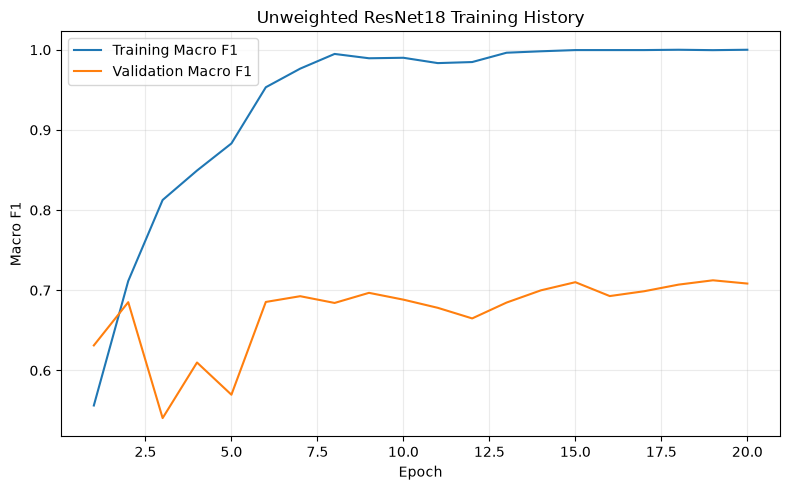

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies/figures/unweighted_training_history.png


In [38]:
unweighted_history_df = pd.read_csv(
    UNWEIGHTED_HISTORY_PATH
)

display(unweighted_history_df.tail())

figure, axis = plt.subplots(figsize=(8, 5))

axis.plot(
    unweighted_history_df["epoch"],
    unweighted_history_df["train_macro_f1"],
    label="Training Macro F1",
)

axis.plot(
    unweighted_history_df["epoch"],
    unweighted_history_df[
        "validation_macro_f1"
    ],
    label="Validation Macro F1",
)

axis.set_title(
    "Unweighted ResNet18 Training History"
)
axis.set_xlabel("Epoch")
axis.set_ylabel("Macro F1")
axis.legend()
axis.grid(alpha=0.25)

figure.tight_layout()

unweighted_history_figure = (
    FIGURES_DIR / "unweighted_training_history.png"
)

figure.savefig(
    unweighted_history_figure,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {unweighted_history_figure}")

,model,macro_f1,accuracy,change_from_unweighted
0,Without class weights,0.7124,0.7905,+0.0000
1,With class weights,0.7077,0.7905,-0.0048


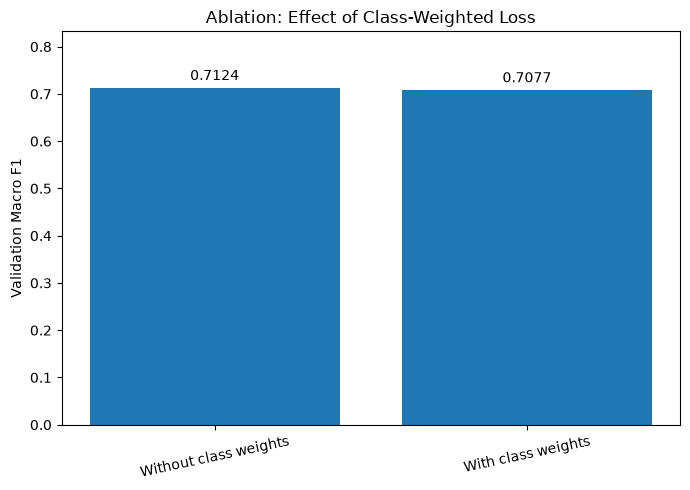

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies/figures/class_weights_ablation.png


**Conclusion.** Class-weighted loss reduced validation Macro F1 by 0.0048. In this run, the natural class distribution generalized better.

In [39]:
unweighted_metrics_json = read_json(
    UNWEIGHTED_METRICS_PATH
)

unweighted_metrics = {
    "model": "Without class weights",
    "macro_f1": float(
        unweighted_metrics_json[
            "validation_macro_f1"
        ]
    ),
    "accuracy": float(
        unweighted_metrics_json[
            "validation_accuracy"
        ]
    ),
}

weighted_metrics = {
    "model": "With class weights",
    "macro_f1": (
        best_tuned_metrics["macro_f1"]
    ),
    "accuracy": (
        best_tuned_metrics["accuracy"]
    ),
}

class_weight_ablation = pd.DataFrame(
    [
        unweighted_metrics,
        weighted_metrics,
    ]
)

class_weight_improvement = (
    weighted_metrics["macro_f1"]
    - unweighted_metrics["macro_f1"]
)

class_weight_ablation[
    "change_from_unweighted"
] = [
    0.0,
    class_weight_improvement,
]

display(
    class_weight_ablation.style.format(
        {
            "macro_f1": "{:.4f}",
            "accuracy": (
                lambda value: ""
                if pd.isna(value)
                else f"{value:.4f}"
            ),
            "change_from_unweighted": "{:+.4f}",
        }
    )
)

save_two_model_comparison(
    class_weight_ablation,
    title="Ablation: Effect of Class-Weighted Loss",
    output_path=FIGURES_DIR / "class_weights_ablation.png",
)

if class_weight_improvement > 0:
    class_weight_conclusion = (
        f"Class-weighted loss improved validation Macro F1 by "
        f"{class_weight_improvement:.4f}. This indicates that giving "
        "additional importance to underrepresented pain classes improved "
        "balanced performance."
    )
elif class_weight_improvement < 0:
    class_weight_conclusion = (
        f"Class-weighted loss reduced validation Macro F1 by "
        f"{abs(class_weight_improvement):.4f}. In this run, the natural "
        "class distribution generalized better."
    )
else:
    class_weight_conclusion = (
        "Weighted and unweighted loss produced the same validation "
        "Macro F1."
    )

display(Markdown(f"**Conclusion.** {class_weight_conclusion}"))

In [40]:
ablation_summary = pd.DataFrame(
    [
        {
            "component": "Data augmentation",
            "without": baseline_metrics["macro_f1"],
            "with": augmented_metrics["macro_f1"],
            "improvement": augmentation_improvement,
            "without_model": "Baseline CNN",
            "with_model": "Augmented CNN",
        },
        {
            "component": "Fine-tuning",
            "without": frozen_metrics["macro_f1"],
            "with": finetuned_metrics["macro_f1"],
            "improvement": fine_tuning_improvement,
            "without_model": "Frozen ResNet18",
            "with_model": "Fine-tuned ResNet18",
        },
        {
            "component": "Transfer learning",
            "without": best_cnn_metrics["macro_f1"],
            "with": best_transfer_metrics["macro_f1"],
            "improvement": transfer_improvement,
            "without_model": best_cnn_metrics["model"],
            "with_model": best_transfer_metrics["model"],
        },
        {
            "component": "Hyperparameter tuning",
            "without": reference_metrics["macro_f1"],
            "with": best_tuned_metrics["macro_f1"],
            "improvement": hyperparameter_improvement,
            "without_model": "Reference configuration",
            "with_model": "Best tuned configuration",
        },
        {
            "component": "Class weights",
            "without": unweighted_metrics["macro_f1"],
            "with": weighted_metrics["macro_f1"],
            "improvement": class_weight_improvement,
            "without_model": "Unweighted loss",
            "with_model": "Weighted loss",
        },
    ]
)

ABLATION_SUMMARY_PATH = (
    ABLATION_DIR / "ablation_summary.csv"
)

ablation_summary.to_csv(
    ABLATION_SUMMARY_PATH,
    index=False,
)

display(
    ablation_summary.style.format(
        {
            "without": "{:.4f}",
            "with": "{:.4f}",
            "improvement": "{:+.4f}",
        }
    )
)

print(f"Saved: {ABLATION_SUMMARY_PATH}")

,component,without,with,improvement,without_model,with_model
0,Data augmentation,0.5977,0.6363,+0.0386,Baseline CNN,Augmented CNN
1,Fine-tuning,0.6433,0.7037,+0.0604,Frozen ResNet18,Fine-tuned ResNet18
2,Transfer learning,0.6363,0.7037,+0.0674,Augmented CNN,Fine-tuned ResNet18
3,Hyperparameter tuning,0.6047,0.7077,+0.1029,Reference configuration,Best tuned configuration
4,Class weights,0.7124,0.7077,-0.0048,Unweighted loss,Weighted loss


Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies/ablation_summary.csv


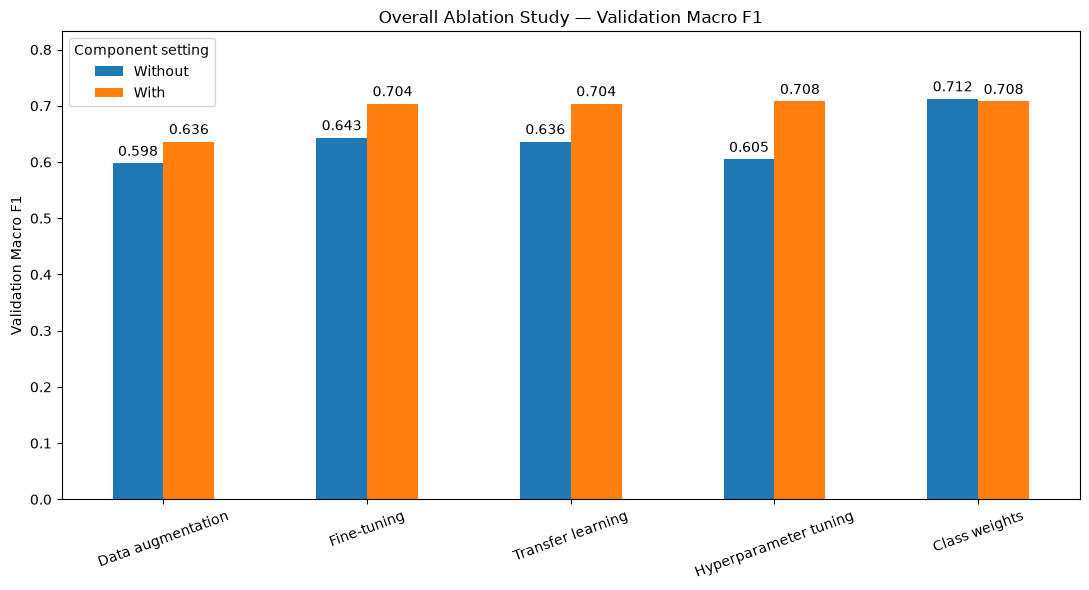

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies/figures/overall_ablation.png


In [41]:
plot_data = (
    ablation_summary[
        ["component", "without", "with"]
    ]
    .set_index("component")
)

figure, axis = plt.subplots(figsize=(11, 6))

plot_data.plot(
    kind="bar",
    ax=axis,
)

axis.set_title(
    "Overall Ablation Study — Validation Macro F1"
)
axis.set_xlabel("")
axis.set_ylabel("Validation Macro F1")
axis.set_ylim(
    0,
    min(
        1.0,
        float(plot_data.to_numpy().max()) + 0.12,
    ),
)
axis.tick_params(
    axis="x",
    rotation=20,
)
axis.legend(
    title="Component setting",
    labels=["Without", "With"],
)

for container in axis.containers:
    axis.bar_label(
        container,
        fmt="%.3f",
        padding=3,
    )

figure.tight_layout()

OVERALL_ABLATION_PATH = (
    FIGURES_DIR / "overall_ablation.png"
)

figure.savefig(
    OVERALL_ABLATION_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {OVERALL_ABLATION_PATH}")

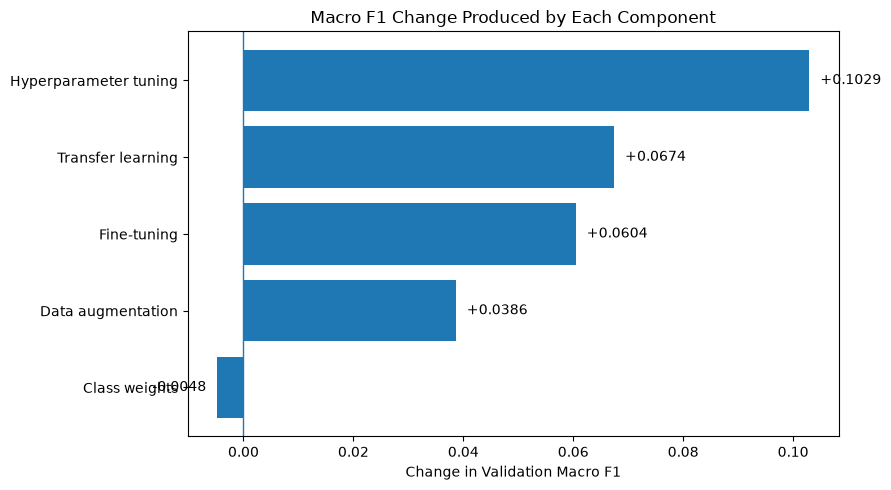

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies/figures/ablation_improvements.png


In [42]:
sorted_improvements = (
    ablation_summary
    .sort_values("improvement")
    .reset_index(drop=True)
)

figure, axis = plt.subplots(figsize=(9, 5))

bars = axis.barh(
    sorted_improvements["component"],
    sorted_improvements["improvement"],
)

axis.axvline(
    0,
    linewidth=1,
)

axis.set_title(
    "Macro F1 Change Produced by Each Component"
)
axis.set_xlabel("Change in Validation Macro F1")

for bar, value in zip(
    bars,
    sorted_improvements["improvement"],
):
    horizontal_alignment = (
        "left" if value >= 0 else "right"
    )

    offset = (
        0.002 if value >= 0 else -0.002
    )

    axis.text(
        value + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.4f}",
        va="center",
        ha=horizontal_alignment,
    )

figure.tight_layout()

IMPROVEMENT_PATH = (
    FIGURES_DIR / "ablation_improvements.png"
)

figure.savefig(
    IMPROVEMENT_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {IMPROVEMENT_PATH}")

In [43]:
positive_components = (
    ablation_summary[
        ablation_summary["improvement"] > 0
    ]
    .sort_values(
        "improvement",
        ascending=False,
    )
)

negative_components = (
    ablation_summary[
        ablation_summary["improvement"] < 0
    ]
    .sort_values("improvement")
)

discussion_lines = []

if not positive_components.empty:
    strongest = positive_components.iloc[0]

    discussion_lines.append(
        f"The largest positive contribution came from "
        f"**{strongest['component']}**, which increased validation "
        f"Macro F1 by **{strongest['improvement']:.4f}**."
    )

    remaining_positive = positive_components.iloc[1:]

    if not remaining_positive.empty:
        component_text = ", ".join(
            f"{row.component} ({row.improvement:+.4f})"
            for row in remaining_positive.itertuples()
        )

        discussion_lines.append(
            f"Other positive contributions were {component_text}."
        )

if not negative_components.empty:
    component_text = ", ".join(
        f"{row.component} ({row.improvement:+.4f})"
        for row in negative_components.itertuples()
    )

    discussion_lines.append(
        f"The following changes did not improve Macro F1 in the "
        f"controlled comparisons: {component_text}."
    )

discussion_lines.append(
    "These results should be interpreted as controlled empirical evidence "
    "for this dataset and split, rather than proof that each component will "
    "always have the same effect on another dataset."
)

display(
    Markdown(
        "### Ablation discussion\n\n"
        + "\n\n".join(discussion_lines)
    )
)

### Ablation discussion

The largest positive contribution came from **Hyperparameter tuning**, which increased validation Macro F1 by **0.1029**.

Other positive contributions were Transfer learning (+0.0674), Fine-tuning (+0.0604), Data augmentation (+0.0386).

The following changes did not improve Macro F1 in the controlled comparisons: Class weights (-0.0048).

These results should be interpreted as controlled empirical evidence for this dataset and split, rather than proof that each component will always have the same effect on another dataset.

In [44]:
best_component_row = (
    ablation_summary
    .sort_values(
        "improvement",
        ascending=False,
    )
    .iloc[0]
)

phase_8_summary = {
    "primary_metric": "validation_macro_f1",
    "test_set_used": False,
    "class_weight_ablation_trained": True,
    "best_positive_component": (
        str(best_component_row["component"])
    ),
    "best_positive_improvement": float(
        best_component_row["improvement"]
    ),
    "experiments": (
        ablation_summary.to_dict(
            orient="records"
        )
    ),
    "outputs": {
        "ablation_summary_csv": str(
            ABLATION_SUMMARY_PATH.relative_to(
                PROJECT_ROOT
            )
        ),
        "overall_ablation_figure": str(
            OVERALL_ABLATION_PATH.relative_to(
                PROJECT_ROOT
            )
        ),
        "improvement_figure": str(
            IMPROVEMENT_PATH.relative_to(
                PROJECT_ROOT
            )
        ),
        "unweighted_checkpoint": str(
            UNWEIGHTED_CHECKPOINT_PATH.relative_to(
                PROJECT_ROOT
            )
        ),
    },
}

PHASE_8_SUMMARY_PATH = (
    ABLATION_DIR / "phase_8_summary.json"
)

with PHASE_8_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        phase_8_summary,
        output_file,
        indent=4,
    )

print(f"Saved: {PHASE_8_SUMMARY_PATH}")

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/ablation_studies/phase_8_summary.json


In [45]:
expected_outputs = [
    ABLATION_SUMMARY_PATH,
    PHASE_8_SUMMARY_PATH,
    FIGURES_DIR / "augmentation_ablation.png",
    FIGURES_DIR / "fine_tuning_ablation.png",
    FIGURES_DIR / "transfer_learning_ablation.png",
    FIGURES_DIR / "hyperparameter_ablation.png",
    FIGURES_DIR / "class_weights_ablation.png",
    FIGURES_DIR / "overall_ablation.png",
    FIGURES_DIR / "ablation_improvements.png",
    UNWEIGHTED_CHECKPOINT_PATH,
    UNWEIGHTED_HISTORY_PATH,
    UNWEIGHTED_METRICS_PATH,
]

output_check = pd.DataFrame(
    {
        "output": [
            str(path.relative_to(PROJECT_ROOT))
            for path in expected_outputs
        ],
        "exists": [
            path.exists()
            for path in expected_outputs
        ],
    }
)

display(output_check)

assert output_check["exists"].all(), (
    "One or more expected Phase 8 outputs are missing."
)

print(
    "Phase 8 completed successfully. "
    "All expected outputs exist."
)

,output,exists
0,results/ablation_studies/ablation_summary.csv,True
1,results/ablation_studies/phase_8_summary.json,True
2,results/ablation_studies/figures/augmentation_...,True
3,results/ablation_studies/figures/fine_tuning_a...,True
4,results/ablation_studies/figures/transfer_lear...,True
5,results/ablation_studies/figures/hyperparamete...,True
6,results/ablation_studies/figures/class_weights...,True
7,results/ablation_studies/figures/overall_ablat...,True
8,results/ablation_studies/figures/ablation_impr...,True
9,results/ablation_studies/checkpoints/resnet18_...,True


Phase 8 completed successfully. All expected outputs exist.
